Logistic Regression and Naive Bayes 

AI : In this notebook I train two models: Logistic Regression and Complement Naive Bayes. Both of them can work directly on sparse matrices so I removed the SVD step. This was also the reason the old Naive Bayes was broken - SVD produced negative values which `MultinomialNB` cannot handle. I also use the full 549k dataset for both models instead of a small sample.

## 1. Import Libraries

In [19]:
import os
import re
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

Configuration

In [20]:
CONFIG = {
    "data_path":    "../preprocessing-dataset/processed_data.csv",
    "result_dir":   "result",
    "text_column":  "processed_text",
    "url_column":   "URL",
    "label_column": "Label",
    "test_size":    0.2,
    "random_state": 42,
    "max_iter":     1000,   # LogisticRegression
    "nb_alpha":     0.1,    # ComplementNB smoothing
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)
print("Result directory ready:", CONFIG["result_dir"])

Result directory ready: result


Load the Dataset
load the full dataset, all 549,346 rows.

In [21]:
df = pd.read_csv(CONFIG["data_path"])
print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")
df.head()

Dataset shape: (549346, 3)
Label distribution:
Label
good    392924
bad     156422
Name: count, dtype: int64


,URL,Label,processed_text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,nobel it 70ffb52d079109dca5664cce6f317373782 l...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,thewhiskeydreg com wp content theme widescreen...


URL Features

AI : I extract 6 features from the raw URL text. These features capture things that the bag-of-words model cannot see, like whether the URL has an IP address or how many subdomains it has. I will use these for Logistic Regression only.

In [22]:
def extract_url_features(url: str) -> list[float]:
    """Extract handcrafted lexical features from a raw URL string.

    Args:
        url: The raw URL string to analyse.

    Returns:
        A list of six numeric features:
        [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth].
    """
    url = str(url)
    url_length     = len(url)
    num_dots       = url.count('.')
    num_digits     = sum(c.isdigit() for c in url)
    num_special    = sum(c in '@-_=?&' for c in url)
    has_ip         = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0
    subdomain_depth = (
        max(0, len(url.split('/')[2].split('.')) - 2)
        if '//' in url else 0
    )
    return [url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth]


url_features = np.array(
    [extract_url_features(u) for u in df[CONFIG["url_column"]]],
    dtype=np.float32,
)
print(f"URL feature matrix shape: {url_features.shape}")
print(f"Feature names: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth")

URL feature matrix shape: (549346, 6)
Feature names: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth


Split the Data
80/20 random split on the full dataset. The vectorizer will be fitted after this step so it only sees training data.

In [23]:
y = df[CONFIG["label_column"]].values
text = df[CONFIG["text_column"]].fillna("").astype(str).values

(
    text_train, text_test,
    url_feat_train, url_feat_test,
    y_train, y_test,
) = train_test_split(
    text, url_features, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

print(f"Train samples: {len(y_train):,}")
print(f"Test  samples: {len(y_test):,}")

Train samples: 439,476
Test  samples: 109,870


Fit TF-IDF on Training Data

AI : I fit a fresh `TfidfVectorizer` on the training text only. I do not reuse the old `vectorizer.pkl` because that one was fitted on all data which causes leakage. The same vectorizer object is used for both Logistic Regression and Naive Bayes.

In [24]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(text_train)
X_test_tfidf  = tfidf.transform(text_test)

print(f"Vocabulary size:          {len(tfidf.vocabulary_):,}")
print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test  TF-IDF shape: {X_test_tfidf.shape}")

Vocabulary size:          400,328
Train TF-IDF shape: (439476, 400328)
Test  TF-IDF shape: (109870, 400328)


Prepare Features for Logistic Regression

AI : I scale the 6 URL features using `StandardScaler` because the raw values have very different ranges. Then I combine the scaled URL features with the TF-IDF matrix using `scipy.sparse.hstack`.

In [25]:
scaler = StandardScaler()
url_feat_train_scaled = scaler.fit_transform(url_feat_train)
url_feat_test_scaled  = scaler.transform(url_feat_test)

X_train_lr = scipy.sparse.hstack(
    [X_train_tfidf, scipy.sparse.csr_matrix(url_feat_train_scaled)]
).tocsr()
X_test_lr = scipy.sparse.hstack(
    [X_test_tfidf, scipy.sparse.csr_matrix(url_feat_test_scaled)]
).tocsr()

print(f"LR train feature shape: {X_train_lr.shape}")
print(f"LR test  feature shape: {X_test_lr.shape}")

LR train feature shape: (439476, 400334)
LR test  feature shape: (109870, 400334)


Train Logistic Regression

AI: I train Logistic Regression using `solver=saga` which works well on large sparse data. I did not use `class_weight=balanced` here because it made the accuracy drop to around 68% on this dataset.

In [26]:
logreg = LogisticRegression(
    solver="saga",
    max_iter=CONFIG["max_iter"],
    random_state=CONFIG["random_state"],
)
logreg.fit(X_train_lr, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


c:\Users\RANON TRASH\Desktop\final-year-project\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Results - Logistic Regression


In [27]:
y_pred_lr = logreg.predict(X_test_lr)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression — Test Accuracy: {acc_lr:.4f}")

Logistic Regression — Test Accuracy: 0.9249


In [28]:
report_lr = classification_report(y_test, y_pred_lr)
print("Logistic Regression — Classification Report")
print(report_lr)

Logistic Regression — Classification Report
              precision    recall  f1-score   support

         bad       0.95      0.78      0.85     31285
        good       0.92      0.98      0.95     78585

    accuracy                           0.92    109870
   macro avg       0.93      0.88      0.90    109870
weighted avg       0.93      0.92      0.92    109870



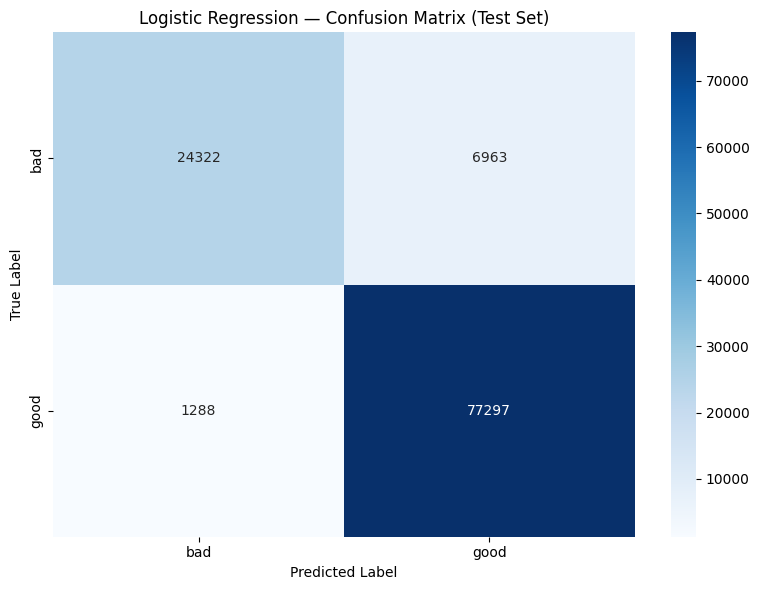

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
labels = sorted(set(y))

fig_lr, ax_lr = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax_lr,
)
ax_lr.set_title("Logistic Regression — Confusion Matrix (Test Set)")
ax_lr.set_xlabel("Predicted Label")
ax_lr.set_ylabel("True Label")
plt.tight_layout()
plt.show()

Train Complement Naive Bayes

AI : I use `ComplementNB` instead of `MultinomialNB`. It works better on imbalanced data and it does not need the SVD step. I do not add the URL features here because mixing them with the sparse TF-IDF would mess up how the model works.

In [30]:
nb = ComplementNB(alpha=CONFIG["nb_alpha"])
nb.fit(X_train_tfidf, y_train)
print("Complement Naive Bayes trained.")

Complement Naive Bayes trained.


Results - Complement Naive Bayes

In [31]:
y_pred_nb = nb.predict(X_test_tfidf)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Complement Naive Bayes — Test Accuracy: {acc_nb:.4f}")

Complement Naive Bayes — Test Accuracy: 0.9698


In [32]:
report_nb = classification_report(y_test, y_pred_nb)
print("Complement Naive Bayes — Classification Report")
print(report_nb)

Complement Naive Bayes — Classification Report
              precision    recall  f1-score   support

         bad       0.93      0.97      0.95     31285
        good       0.99      0.97      0.98     78585

    accuracy                           0.97    109870
   macro avg       0.96      0.97      0.96    109870
weighted avg       0.97      0.97      0.97    109870



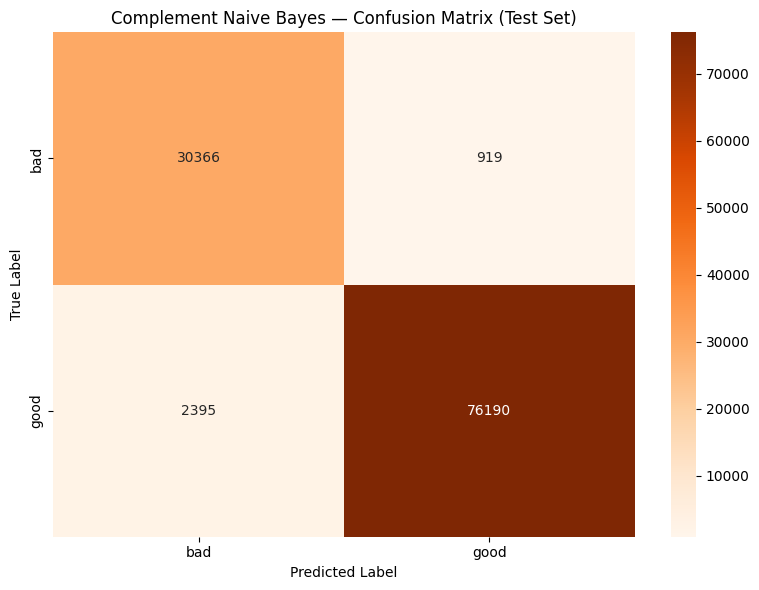

In [33]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig_nb, ax_nb = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax_nb,
)
ax_nb.set_title("Complement Naive Bayes — Confusion Matrix (Test Set)")
ax_nb.set_xlabel("Predicted Label")
ax_nb.set_ylabel("True Label")
plt.tight_layout()
plt.show()

Save File

In [34]:
lr_model_path  = os.path.join(CONFIG["result_dir"], "model_logreg.pkl")
nb_model_path  = os.path.join(CONFIG["result_dir"], "model_nb.pkl")
scaler_path    = os.path.join(CONFIG["result_dir"], "url_scaler.pkl")

with open(lr_model_path, "wb") as f:
    pickle.dump(logreg, f)
print(f"Logistic Regression model saved to {lr_model_path}")

with open(nb_model_path, "wb") as f:
    pickle.dump(nb, f)
print(f"Complement Naive Bayes model saved to {nb_model_path}")

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"URL feature scaler saved to {scaler_path}")

Logistic Regression model saved to result\model_logreg.pkl
Complement Naive Bayes model saved to result\model_nb.pkl
URL feature scaler saved to result\url_scaler.pkl


In [35]:
lr_report_path = os.path.join(CONFIG["result_dir"], "classification_report_logreg.txt")
nb_report_path = os.path.join(CONFIG["result_dir"], "classification_report_nb.txt")

with open(lr_report_path, "w") as f:
    f.write(f"Test Accuracy: {acc_lr:.4f}\n\n")
    f.write(report_lr)
print(f"Logistic Regression report saved to {lr_report_path}")

with open(nb_report_path, "w") as f:
    f.write(f"Test Accuracy: {acc_nb:.4f}\n\n")
    f.write(report_nb)
print(f"Complement Naive Bayes report saved to {nb_report_path}")

Logistic Regression report saved to result\classification_report_logreg.txt
Complement Naive Bayes report saved to result\classification_report_nb.txt


In [36]:
lr_cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_logreg.png")
nb_cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix_nb.png")

fig_lr.savefig(lr_cm_path, dpi=150, bbox_inches="tight")
print(f"Logistic Regression confusion matrix saved to {lr_cm_path}")

fig_nb.savefig(nb_cm_path, dpi=150, bbox_inches="tight")
print(f"Complement Naive Bayes confusion matrix saved to {nb_cm_path}")

Logistic Regression confusion matrix saved to result\confusion_matrix_logreg.png
Complement Naive Bayes confusion matrix saved to result\confusion_matrix_nb.png
